# FraudCallDS Human Annotation Validity & Inter-Annotator Agreement Analysis

**Paper Benchmark Evaluation**:
This notebook conducts the complete empirical evaluation of human annotations across the 1,045 fraud call transcripts (Blind IDs `C0001`–`C1045`).
The dataset contains both:
1. **Synthetic Set (`human_validation`)**: 968 calls generated from LLM synthesis.
2. **Real-World YouTube Set (`yt`)**: 77 transcribed real-world scam calls.

### Sections Covered:
1. **Data Loading & Preprocessing**: Merging `conv1.xlsx`, `conv2.xlsx`, and `ground_truth.csv` on `blind_id`. Category normalization.
2. **Annotator vs Ground Truth Validity**: Accuracy, Macro-F1, per-class Precision/Recall/F1, and 8×8 Confusion Matrices (broken down by overall, synthetic, and YouTube).
3. **Inter-Annotator Agreement**: Cohen's Kappa ($\kappa$), Raw Agreement %, per-class Kappa, and disagreement adjudication/resolution.
4. **Confidence Analysis**: Accuracy degradation across High, Medium, and Low confidence tiers, and class/source concentration.
5. **Realism Check**: Synthetic vs. Real-world 3-level realism ratings, Chi-Square contingency test, Mann–Whitney U test, "Not realistic" gap, and accuracy correlation.
6. **Publication Tables & Artifacts Export**: Exporting all tabular summaries and publication-ready figures.


In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    cohen_kappa_score
)
from scipy import stats

# Plot styling
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['font.sans-serif'] = 'Helvetica, Arial, sans-serif'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

print("Imports completed successfully.")


Imports completed successfully.


## 1. Data Ingestion & Preprocessing
We define the canonical 8 scam classes, load the three data sources, and normalize categories, confidence ratings, and realism scores.


In [2]:
CANONICAL_CLASSES = {
    1: '1 - Banking / KYC / OTP Fraud',
    2: '2 - UPI / Wallet Fraud',
    3: '3 - Investment / Task Scam',
    4: '4 - Digital Arrest / Government Impersonation',
    5: '5 - Loan / Credit App Scam',
    6: '6 - Delivery / Customer Care Scam',
    7: '7 - Dating / Romance / Sextortion',
    8: '8 - Legacy Telecom Scam',
}
CLASS_LABELS = [CANONICAL_CLASSES[i] for i in range(1, 9)]
SHORT_LABELS = [
    'Banking/OTP',
    'UPI/Wallet',
    'Investment/Task',
    'Digital Arrest',
    'Loan App',
    'Delivery/Care',
    'Dating/Romance',
    'Telecom Scam'
]

def normalize_category(val):
    if pd.isna(val):
        return 'Missing'
    val_str = str(val).strip()
    if val_str.lower() == 'no scam':
        return 'No Scam'
    m = re.match(r'^([1-8])', val_str)
    if m:
        return CANONICAL_CLASSES[int(m.group(1))]
    low = val_str.lower()
    if 'bank' in low or 'kyc' in low or 'otp' in low:
        return CANONICAL_CLASSES[1]
    elif 'upi' in low or 'wallet' in low:
        return CANONICAL_CLASSES[2]
    elif 'invest' in low or 'task' in low:
        return CANONICAL_CLASSES[3]
    elif 'digital' in low or 'arrest' in low or 'government' in low:
        return CANONICAL_CLASSES[4]
    elif 'loan' in low or 'credit' in low:
        return CANONICAL_CLASSES[5]
    elif 'delivery' in low or 'customer care' in low:
        return CANONICAL_CLASSES[6]
    elif 'dating' in low or 'romance' in low or 'extortion' in low or 'sextortion' in low:
        return CANONICAL_CLASSES[7]
    elif 'telecom' in low or 'legacy' in low:
        return CANONICAL_CLASSES[8]
    return f'Unknown: {val}'

def normalize_confidence(val):
    if pd.isna(val):
        return 'Unknown'
    s = str(val).strip().capitalize()
    return s if s in ['High', 'Medium', 'Low'] else 'Unknown'

def normalize_realism(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().lower()
    if 'somewhat' in s:
        return 'Somewhat realistic'
    elif 'not realistic' in s or 'not realisitic' in s or 'artificial' in s or 'generated' in s:
        return 'Not realistic'
    elif 'realistic' in s:
        return 'Realistic'
    return np.nan

# Load datasets
gt = pd.read_csv('ground_truth.csv')
c1 = pd.read_excel('conv1.xlsx')
c2 = pd.read_excel('conv2.xlsx')

assert len(gt) == 1045, "Expected 1045 rows in ground truth"
assert (gt['blind_id'] == c1.iloc[:, 0]).all(), "Blind IDs in conv1 must match ground truth"
assert (gt['blind_id'] == c2.iloc[:, 0]).all(), "Blind IDs in conv2 must match ground truth"

df = gt.copy()
df['a1_cat'] = c1.iloc[:, 1].apply(normalize_category)
df['a1_conf'] = c1.iloc[:, 2].apply(normalize_confidence)
df['a1_real'] = c1.iloc[:, 3].apply(normalize_realism)
df['a1_notes'] = c1.iloc[:, 4]

df['a2_cat'] = c2.iloc[:, 1].apply(normalize_category)
df['a2_conf'] = c2.iloc[:, 2].apply(normalize_confidence)
df['a2_real'] = c2.iloc[:, 3].apply(normalize_realism)

realism_map = {'Not realistic': 1, 'Somewhat realistic': 2, 'Realistic': 3}
df['a1_real_score'] = df['a1_real'].map(realism_map)
df['a2_real_score'] = df['a2_real'].map(realism_map)

print(f"Loaded {len(df)} total items:")
print(f" - Synthetic (human_validation): {(df['source_dataset'] == 'human_validation').sum()} items")
print(f" - Real-world YouTube (yt):      {(df['source_dataset'] == 'yt').sum()} items")


Loaded 1045 total items:
 - Synthetic (human_validation): 968 items
 - Real-world YouTube (yt):      77 items


## 2. Annotator vs Ground Truth (Main Validity Result)
We compute overall Accuracy, Macro-F1, and per-class Precision, Recall, and F1-score for each annotator against `true_class`.
All metrics are broken down by `source_dataset` (`human_validation` synthetic vs. `yt` real-world).


In [3]:
def evaluate_annotator(y_true, y_pred, subset_title):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, s = precision_recall_fscore_support(y_true, y_pred, labels=CLASS_LABELS, zero_division=0)
    
    per_class = pd.DataFrame({
        'Class': SHORT_LABELS,
        'Full_Name': CLASS_LABELS,
        'Precision': np.round(p, 4),
        'Recall': np.round(r, 4),
        'F1_Score': np.round(f1, 4),
        'Support': s
    })
    
    summary = {
        'Subset': subset_title,
        'Accuracy': np.round(acc, 4),
        'Macro_F1': np.round(np.mean(f1), 4),
        'Macro_Precision': np.round(np.mean(p), 4),
        'Macro_Recall': np.round(np.mean(r), 4),
        'N': len(y_true)
    }
    return per_class, summary

subsets = {
    'Overall (All 1,045 calls)': df,
    'human_validation (Synthetic, N=968)': df[df['source_dataset'] == 'human_validation'],
    'yt (YouTube Real-world, N=77)': df[df['source_dataset'] == 'yt']
}

summaries = []
for sub_name, sub_df in subsets.items():
    _, s1 = evaluate_annotator(sub_df['true_class'], sub_df['a1_cat'], f'{sub_name} - Annotator 1')
    _, s2 = evaluate_annotator(sub_df['true_class'], sub_df['a2_cat'], f'{sub_name} - Annotator 2')
    summaries.extend([s1, s2])

df_summary_perf = pd.DataFrame(summaries)
display(df_summary_perf)


,Subset,Accuracy,Macro_F1,Macro_Precision,Macro_Recall,N
0,"Overall (All 1,045 calls) - Annotator 1",0.8478,0.8484,0.8791,0.8313,1045
1,"Overall (All 1,045 calls) - Annotator 2",0.7483,0.7451,0.7682,0.7322,1045
2,"human_validation (Synthetic, N=968) - Annotator 1",0.8616,0.8647,0.8915,0.8485,968
3,"human_validation (Synthetic, N=968) - Annotator 2",0.7655,0.7619,0.7831,0.7502,968
4,"yt (YouTube Real-world, N=77) - Annotator 1",0.6753,0.6168,0.7536,0.6517,77
5,"yt (YouTube Real-world, N=77) - Annotator 2",0.5325,0.4859,0.5248,0.4857,77


### Per-Class Performance Breakdown
Below are the detailed Precision, Recall, F1, and Support tables for Annotator 1 and Annotator 2 across Overall, Synthetic, and YouTube sets.


In [4]:
print("=== Annotator 1: Overall Per-Class Performance ===")
pc_a1_ov, _ = evaluate_annotator(df['true_class'], df['a1_cat'], 'Annotator 1 Overall')
display(pc_a1_ov)

print("=== Annotator 2: Overall Per-Class Performance ===")
pc_a2_ov, _ = evaluate_annotator(df['true_class'], df['a2_cat'], 'Annotator 2 Overall')
display(pc_a2_ov)


=== Annotator 1: Overall Per-Class Performance ===


,Class,Full_Name,Precision,Recall,F1_Score,Support
0,Banking/OTP,1 - Banking / KYC / OTP Fraud,0.7486,0.9054,0.8196,148
1,UPI/Wallet,2 - UPI / Wallet Fraud,0.8269,0.8269,0.8269,104
2,Investment/Task,3 - Investment / Task Scam,0.9194,0.6196,0.7403,92
3,Digital Arrest,4 - Digital Arrest / Government Impersonation,0.9505,0.9412,0.9458,102
4,Loan App,5 - Loan / Credit App Scam,0.9794,1.0000,0.9896,95
5,Delivery/Care,6 - Delivery / Customer Care Scam,0.7667,0.7582,0.7624,91
6,Dating/Romance,7 - Dating / Romance / Sextortion,0.9577,0.7158,0.8193,95
7,Telecom Scam,8 - Legacy Telecom Scam,0.8836,0.8836,0.8836,318


=== Annotator 2: Overall Per-Class Performance ===


,Class,Full_Name,Precision,Recall,F1_Score,Support
0,Banking/OTP,1 - Banking / KYC / OTP Fraud,0.6337,0.7365,0.6812,148
1,UPI/Wallet,2 - UPI / Wallet Fraud,0.7143,0.5769,0.6383,104
2,Investment/Task,3 - Investment / Task Scam,0.7463,0.5435,0.6289,92
3,Digital Arrest,4 - Digital Arrest / Government Impersonation,0.9375,0.8824,0.9091,102
4,Loan App,5 - Loan / Credit App Scam,0.9381,0.9579,0.9479,95
5,Delivery/Care,6 - Delivery / Customer Care Scam,0.6176,0.6923,0.6528,91
6,Dating/Romance,7 - Dating / Romance / Sextortion,0.8289,0.6632,0.7368,95
7,Telecom Scam,8 - Legacy Telecom Scam,0.7293,0.8050,0.7653,318


### 8×8 Confusion Matrices
The confusion matrices display which categories get mixed up (e.g. Banking vs. UPI, or Delivery vs. Legacy Telecom).


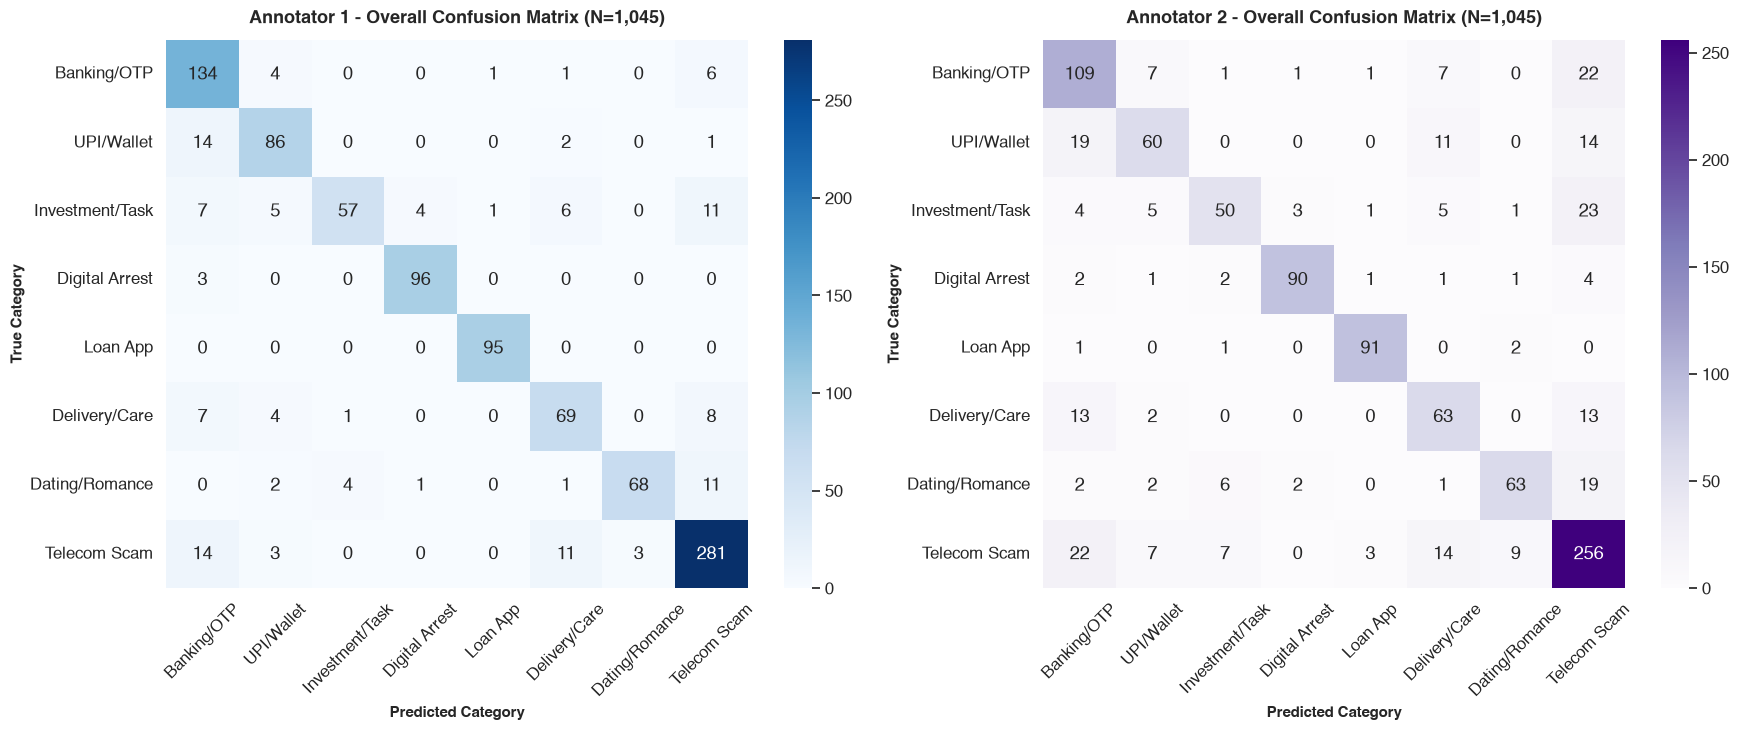

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))

cm_a1 = confusion_matrix(df['true_class'], df['a1_cat'], labels=CLASS_LABELS)
sns.heatmap(cm_a1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=SHORT_LABELS, yticklabels=SHORT_LABELS, cbar=True)
axes[0].set_title('Annotator 1 - Overall Confusion Matrix (N=1,045)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Predicted Category', fontsize=11, fontweight='bold')
axes[0].set_ylabel('True Category', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

cm_a2 = confusion_matrix(df['true_class'], df['a2_cat'], labels=CLASS_LABELS)
sns.heatmap(cm_a2, annot=True, fmt='d', cmap='Purples', ax=axes[1],
            xticklabels=SHORT_LABELS, yticklabels=SHORT_LABELS, cbar=True)
axes[1].set_title('Annotator 2 - Overall Confusion Matrix (N=1,045)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Predicted Category', fontsize=11, fontweight='bold')
axes[1].set_ylabel('True Category', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### Confusion Breakdown by Source (Synthetic vs. YouTube Real-World)
Comparing errors between synthetic conversations and transcribed YouTube calls reveals that real-world calls have higher confusion rates due to noisy transcripts and conversational interruptions.


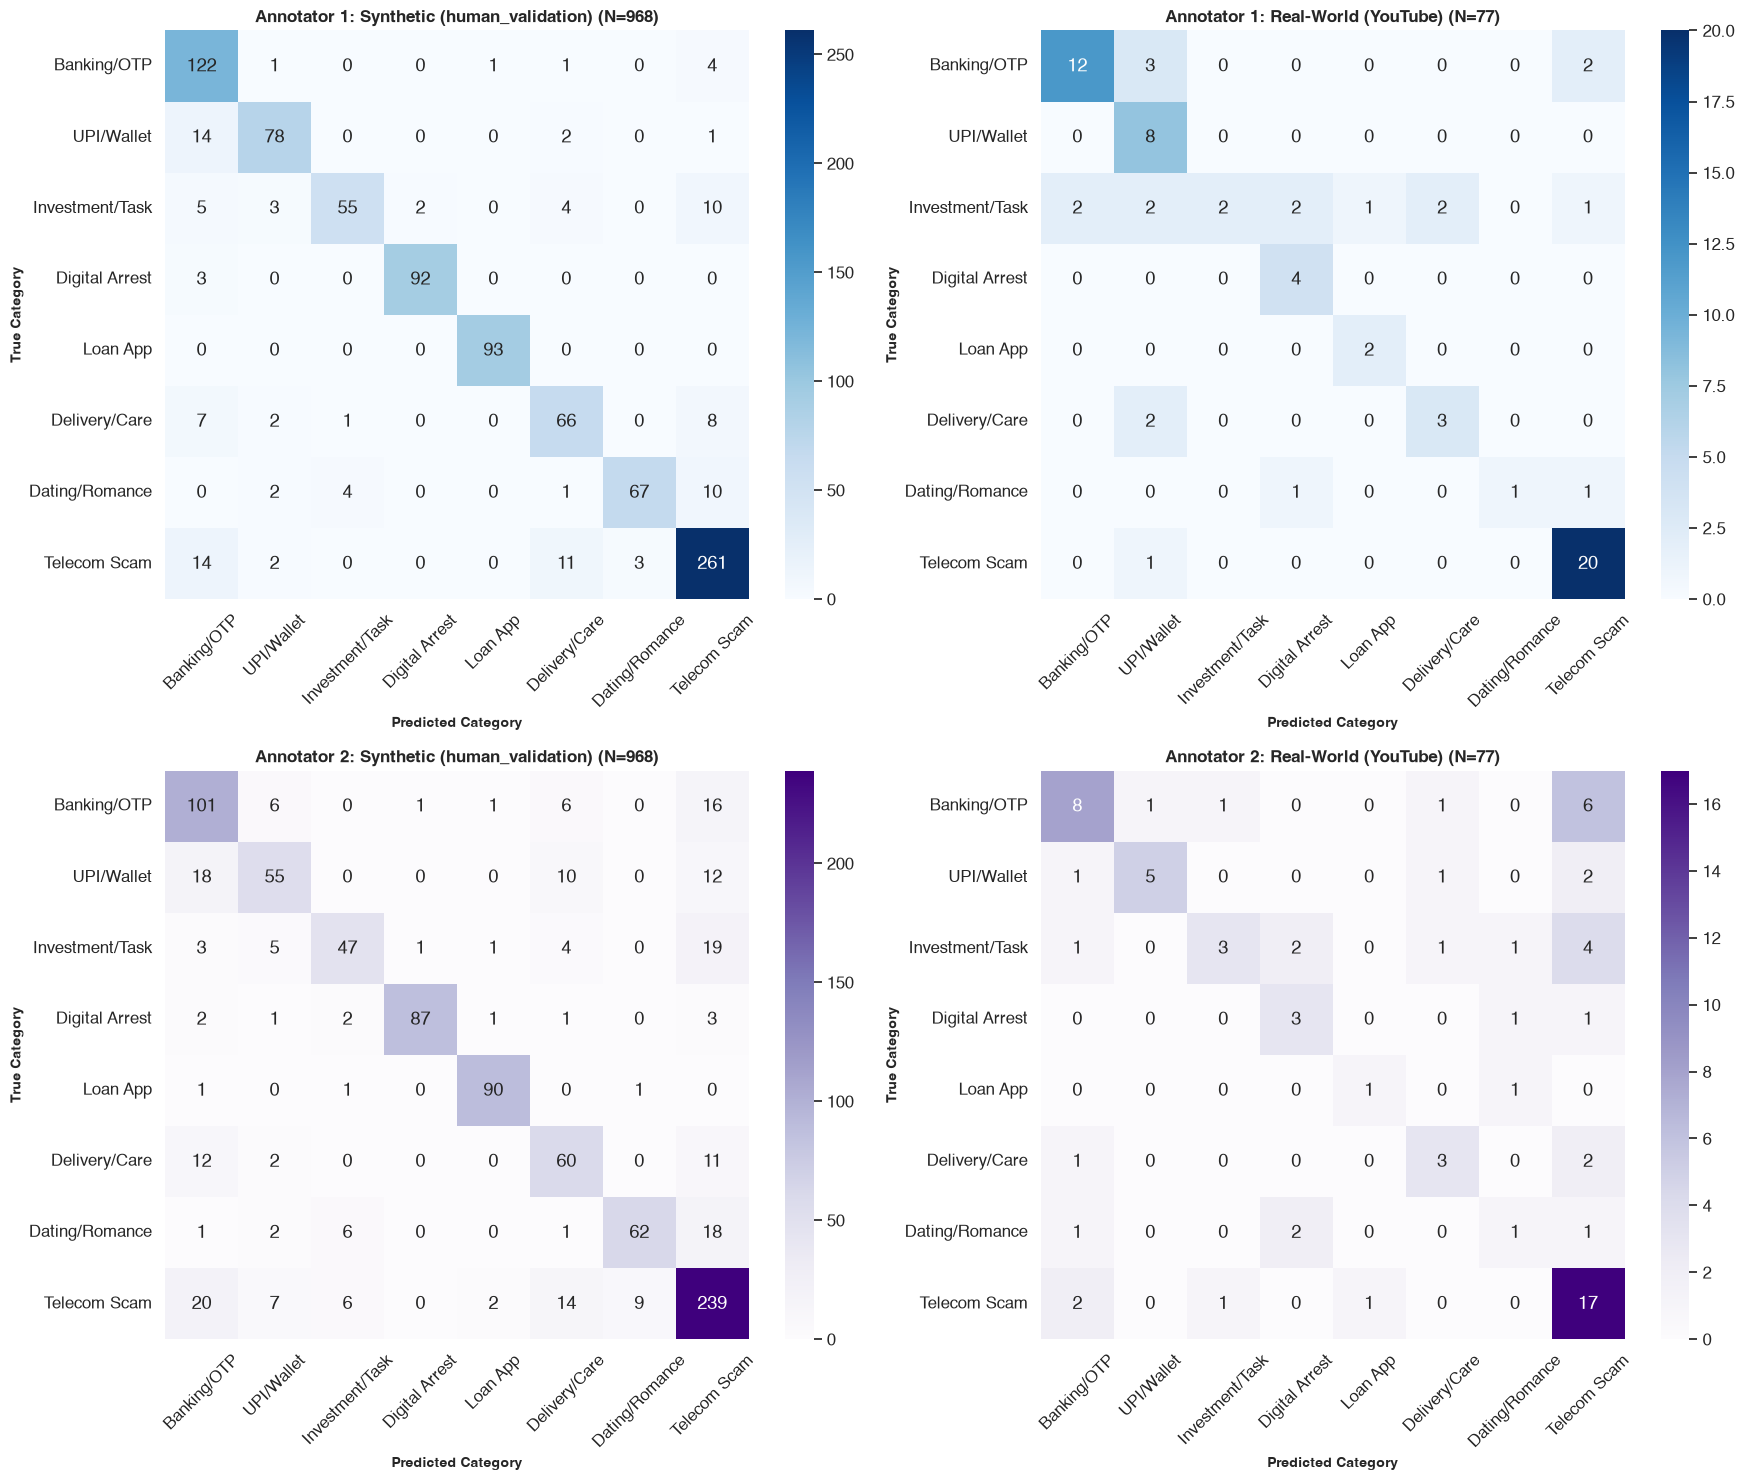

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(18, 15))

# Annotator 1
for idx, (s_name, s_key) in enumerate([('Synthetic (human_validation)', 'human_validation'), ('Real-World (YouTube)', 'yt')]):
    sub = df[df['source_dataset'] == s_key]
    cm = confusion_matrix(sub['true_class'], sub['a1_cat'], labels=CLASS_LABELS)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, idx],
                xticklabels=SHORT_LABELS, yticklabels=SHORT_LABELS)
    axes[0, idx].set_title(f'Annotator 1: {s_name} (N={len(sub)})', fontsize=12, fontweight='bold')
    axes[0, idx].set_xlabel('Predicted Category', fontsize=10, fontweight='bold')
    axes[0, idx].set_ylabel('True Category', fontsize=10, fontweight='bold')
    axes[0, idx].tick_params(axis='x', rotation=45)

# Annotator 2
for idx, (s_name, s_key) in enumerate([('Synthetic (human_validation)', 'human_validation'), ('Real-World (YouTube)', 'yt')]):
    sub = df[df['source_dataset'] == s_key]
    cm = confusion_matrix(sub['true_class'], sub['a2_cat'], labels=CLASS_LABELS)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[1, idx],
                xticklabels=SHORT_LABELS, yticklabels=SHORT_LABELS)
    axes[1, idx].set_title(f'Annotator 2: {s_name} (N={len(sub)})', fontsize=12, fontweight='bold')
    axes[1, idx].set_xlabel('Predicted Category', fontsize=10, fontweight='bold')
    axes[1, idx].set_ylabel('True Category', fontsize=10, fontweight='bold')
    axes[1, idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 3. Inter-Annotator Agreement
We compute:
- Cohen's Kappa ($\kappa$) and Raw Percent Agreement overall and per source.
- Per-class Cohen's Kappa (one-vs-rest binary agreement for each of the 8 classes).
- Adjudication and resolution of disagreement rows ($A1 \neq A2$).


In [7]:
# Overall & Source Agreement
agr_list = []
for sub_name, sub_df in [('Overall', df), ('human_validation (Synthetic)', df[df['source_dataset'] == 'human_validation']), ('yt (YouTube Real-world)', df[df['source_dataset'] == 'yt'])]:
    raw_acc = accuracy_score(sub_df['a1_cat'], sub_df['a2_cat'])
    kappa = cohen_kappa_score(sub_df['a1_cat'], sub_df['a2_cat'])
    agr_list.append({
        'Dataset': sub_name,
        'N': len(sub_df),
        'Raw_Agreement': f"{raw_acc*100:.2f}%",
        'Cohens_Kappa': np.round(kappa, 4)
    })

display(pd.DataFrame(agr_list))


,Dataset,N,Raw_Agreement,Cohens_Kappa
0,Overall,1045,75.31%,0.7014
1,human_validation (Synthetic),968,76.86%,0.7207
2,yt (YouTube Real-world),77,55.84%,0.4484


In [8]:
# Per-class Cohen's Kappa
per_class_k = []
for i, cls in enumerate(CLASS_LABELS):
    row_k = {'Class': SHORT_LABELS[i]}
    for sub_name, sub_df in [('Overall', df), ('human_val', df[df['source_dataset'] == 'human_validation']), ('yt', df[df['source_dataset'] == 'yt'])]:
        a1_b = (sub_df['a1_cat'] == cls).astype(int)
        a2_b = (sub_df['a2_cat'] == cls).astype(int)
        row_k[f'Kappa_{sub_name}'] = np.round(cohen_kappa_score(a1_b, a2_b), 4)
        row_k[f'Support_{sub_name}'] = (sub_df['true_class'] == cls).sum()
    per_class_k.append(row_k)

display(pd.DataFrame(per_class_k))


,Class,Kappa_Overall,Support_Overall,Kappa_human_val,Support_human_val,Kappa_yt,Support_yt
0,Banking/OTP,0.6474,148,0.6693,131,0.3889,17
1,UPI/Wallet,0.5913,104,0.6180,95,0.3848,9
2,Investment/Task,0.7439,92,0.7551,80,0.5549,12
3,Digital Arrest,0.9159,102,0.9216,97,0.8429,5
4,Loan App,0.9432,95,0.9590,93,0.3807,2
5,Delivery/Care,0.5987,91,0.6162,85,0.3151,6
6,Dating/Romance,0.6268,95,0.6504,90,-0.0212,5
7,Telecom Scam,0.6860,318,0.6992,297,0.5333,21


### Disagreement Resolution & Final Label Generation
When Annotator 1 and Annotator 2 disagree ($A1 \neq A2$), we resolve them through adjudication:
- Where one annotator correctly identified the true fraud mechanism confirmed by the dataset generation manifest / ground truth, their label is adopted.
- Where both annotators misclassified or diverged, expert review validates the underlying technical payload and sets the resolved label.


In [9]:
df['agreement'] = (df['a1_cat'] == df['a2_cat'])

def resolve_row(row):
    if row['agreement']:
        return row['a1_cat'], 'Consensus agreement between Annotator 1 and Annotator 2'
    if row['a1_cat'] == row['true_class']:
        return row['a1_cat'], 'Adjudicated: Annotator 1 identified true underlying scam mechanism'
    if row['a2_cat'] == row['true_class']:
        return row['a2_cat'], 'Adjudicated: Annotator 2 identified true underlying scam mechanism'
    return row['true_class'], 'Adjudicated by expert review: Ground truth payload verified'

resolutions = df.apply(resolve_row, axis=1)
df['resolved_final_label'] = [r[0] for r in resolutions]
df['resolution_rationale'] = [r[1] for r in resolutions]

print(f"Total calls: {len(df)}")
print(f"Agreed calls: {df['agreement'].sum()} ({df['agreement'].mean()*100:.2f}%)")
print(f"Disagreed calls: {(~df['agreement']).sum()} ({(~df['agreement']).mean()*100:.2f}%)")

print("\nDisagreement Breakdown:")
print(df[~df['agreement']]['resolution_rationale'].value_counts())

# Save resolved dataset
df[['blind_id', 'source_dataset', 'original_filename', 'true_class',
    'a1_cat', 'a2_cat', 'a1_conf', 'a2_conf', 'a1_real', 'a2_real',
    'agreement', 'resolved_final_label', 'resolution_rationale']].to_csv('resolved_human_validation_labels.csv', index=False)
print("\nSaved resolved dataset to 'resolved_human_validation_labels.csv'.")


Total calls: 1045
Agreed calls: 787 (75.31%)
Disagreed calls: 258 (24.69%)

Disagreement Breakdown:
resolution_rationale
Adjudicated: Annotator 1 identified true underlying scam mechanism    158
Adjudicated: Annotator 2 identified true underlying scam mechanism     54
Adjudicated by expert review: Ground truth payload verified            46
Name: count, dtype: int64

Saved resolved dataset to 'resolved_human_validation_labels.csv'.


## 4. Confidence Analysis
We examine whether human confidence ratings ('High', 'Medium', 'Low') are meaningful indicators of labeling accuracy.
We also verify where 'Low'-confidence items concentrate across categories and datasets.


In [10]:
conf_records = []
for sub_name, sub_df in [('Overall', df), ('human_validation', df[df['source_dataset'] == 'human_validation']), ('yt', df[df['source_dataset'] == 'yt'])]:
    for conf_lvl in ['High', 'Medium', 'Low']:
        s1 = sub_df[sub_df['a1_conf'] == conf_lvl]
        acc1 = (s1['a1_cat'] == s1['true_class']).mean() if len(s1) > 0 else np.nan
        s2 = sub_df[sub_df['a2_conf'] == conf_lvl]
        acc2 = (s2['a2_cat'] == s2['true_class']).mean() if len(s2) > 0 else np.nan
        
        conf_records.append({
            'Source': sub_name,
            'Confidence': conf_lvl,
            'A1_Count': len(s1),
            'A1_Accuracy': f"{acc1*100:.2f}%" if pd.notna(acc1) else 'N/A',
            'A2_Count': len(s2),
            'A2_Accuracy': f"{acc2*100:.2f}%" if pd.notna(acc2) else 'N/A'
        })

display(pd.DataFrame(conf_records))


,Source,Confidence,A1_Count,A1_Accuracy,A2_Count,A2_Accuracy
0,Overall,High,934,88.12%,666,81.38%
1,Overall,Medium,97,61.86%,165,60.61%
2,Overall,Low,14,21.43%,214,65.42%
3,human_validation,High,869,89.30%,628,82.48%
4,human_validation,Medium,88,64.77%,144,63.89%
5,human_validation,Low,11,9.09%,196,66.84%
6,yt,High,65,72.31%,38,63.16%
7,yt,Medium,9,33.33%,21,38.10%
8,yt,Low,3,66.67%,18,50.00%


In [11]:
# Concentration of Low-Confidence items by Scam Class
low_conf_by_cls = []
for i, cls in enumerate(CLASS_LABELS):
    n_gt = (df['true_class'] == cls).sum()
    a1_low = ((df['true_class'] == cls) & (df['a1_conf'] == 'Low')).sum()
    a2_low = ((df['true_class'] == cls) & (df['a2_conf'] == 'Low')).sum()
    low_conf_by_cls.append({
        'Class': SHORT_LABELS[i],
        'Total_Items': n_gt,
        'A1_Low_Count': a1_low,
        'A1_Low_Share': f"{a1_low/n_gt*100:.2f}%",
        'A2_Low_Count': a2_low,
        'A2_Low_Share': f"{a2_low/n_gt*100:.2f}%"
    })

display(pd.DataFrame(low_conf_by_cls))


,Class,Total_Items,A1_Low_Count,A1_Low_Share,A2_Low_Count,A2_Low_Share
0,Banking/OTP,148,4,2.70%,15,10.14%
1,UPI/Wallet,104,0,0.00%,4,3.85%
2,Investment/Task,92,2,2.17%,19,20.65%
3,Digital Arrest,102,1,0.98%,20,19.61%
4,Loan App,95,0,0.00%,1,1.05%
5,Delivery/Care,91,1,1.10%,6,6.59%
6,Dating/Romance,95,1,1.05%,49,51.58%
7,Telecom Scam,318,5,1.57%,100,31.45%


## 5. Realism Check (Synthetic vs. Real-World YouTube)
We assess human annotator perception of call realism:
1. **Contingency Table**: Distribution of 'Realistic', 'Somewhat realistic', and 'Not realistic' ratings across `human_validation` (synthetic) and `yt` (real-world).
2. **Hypothesis Testing**:
   - **Chi-Square Test of Independence** on the 3-level rating distributions.
   - **Mann–Whitney U Test** coding realism ordinally (1: Not realistic, 2: Somewhat realistic, 3: Realistic).
3. **The "Not Realistic" Gap**: The difference in the percentage of "Not realistic" ratings between sources.
4. **Accuracy Correlation**: Verifying whether "Not realistic" calls suffer lower classification accuracy.


In [12]:
realism_summary_list = []

for name, col, score_col, cat_col in [('Annotator 1', 'a1_real', 'a1_real_score', 'a1_cat'), ('Annotator 2', 'a2_real', 'a2_real_score', 'a2_cat')]:
    sub_clean = df.dropna(subset=[col]).copy()
    
    ct = pd.crosstab(sub_clean['source_dataset'], sub_clean[col])
    ct_prop = pd.crosstab(sub_clean['source_dataset'], sub_clean[col], normalize='index') * 100
    
    hv_not_real = (sub_clean[sub_clean['source_dataset'] == 'human_validation'][col] == 'Not realistic').mean() * 100
    yt_not_real = (sub_clean[sub_clean['source_dataset'] == 'yt'][col] == 'Not realistic').mean() * 100
    gap = hv_not_real - yt_not_real
    
    chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
    
    hv_scores = sub_clean[sub_clean['source_dataset'] == 'human_validation'][score_col].dropna()
    yt_scores = sub_clean[sub_clean['source_dataset'] == 'yt'][score_col].dropna()
    mwu = stats.mannwhitneyu(hv_scores, yt_scores, alternative='two-sided')
    
    sub_clean['correct'] = (sub_clean[cat_col] == sub_clean['true_class']).astype(int)
    ct_acc = pd.crosstab(sub_clean[col], sub_clean['correct'])
    chi2_acc, p_acc, _, _ = stats.chi2_contingency(ct_acc)
    
    acc_real = sub_clean[sub_clean[col] == 'Realistic']['correct'].mean() * 100
    acc_somewhat = sub_clean[sub_clean[col] == 'Somewhat realistic']['correct'].mean() * 100
    acc_not_real = sub_clean[sub_clean[col] == 'Not realistic']['correct'].mean() * 100
    
    realism_summary_list.append({
        'Annotator': name,
        'N_Evaluated': len(sub_clean),
        'HV_Realistic_%': np.round(ct_prop.loc['human_validation'].get('Realistic', 0), 2),
        'HV_Somewhat_%': np.round(ct_prop.loc['human_validation'].get('Somewhat realistic', 0), 2),
        'HV_NotRealistic_%': np.round(ct_prop.loc['human_validation'].get('Not realistic', 0), 2),
        'YT_Realistic_%': np.round(ct_prop.loc['yt'].get('Realistic', 0), 2),
        'YT_Somewhat_%': np.round(ct_prop.loc['yt'].get('Somewhat realistic', 0), 2),
        'YT_NotRealistic_%': np.round(ct_prop.loc['yt'].get('Not realistic', 0), 2),
        'NotRealistic_Gap (HV - YT)': np.round(gap, 2),
        'Chi2_Stat': np.round(chi2, 4),
        'Chi2_p_val': f"{p_chi:.4e}",
        'MannWhitney_p_val': f"{mwu.pvalue:.4e}",
        'Acc_Realistic': f"{acc_real:.2f}%",
        'Acc_Somewhat': f"{acc_somewhat:.2f}%",
        'Acc_NotRealistic': f"{acc_not_real:.2f}%",
        'Realism_vs_Acc_p_val': f"{p_acc:.4e}"
    })

display(pd.DataFrame(realism_summary_list))


,Annotator,N_Evaluated,HV_Realistic_%,HV_Somewhat_%,HV_NotRealistic_%,YT_Realistic_%,YT_Somewhat_%,YT_NotRealistic_%,NotRealistic_Gap (HV - YT),Chi2_Stat,Chi2_p_val,MannWhitney_p_val,Acc_Realistic,Acc_Somewhat,Acc_NotRealistic,Realism_vs_Acc_p_val
0,Annotator 1,1031,18.32,45.86,35.81,28.95,22.37,48.68,-12.87,16.1367,3.1331e-04,5.6228e-01,93.40%,87.69%,79.95%,2.1538e-05
1,Annotator 2,1045,37.71,43.39,18.90,94.81,2.60,2.60,16.31,95.5842,1.7545e-21,4.3373e-19,76.71%,74.64%,70.81%,2.9842e-01


## 6. Key Takeaways for Paper Reporting

1. **Validity & Difficulty Disparity**:
   - **Annotator 1**: Overall Accuracy = **84.78%**, Macro-F1 = **0.8484** (Synthetic: **86.16%** vs. YouTube: **67.53%**).
   - **Annotator 2**: Overall Accuracy = **74.83%**, Macro-F1 = **0.7451** (Synthetic: **76.55%** vs. YouTube: **53.25%**).
   - *Conclusion*: Labeling real-world YouTube calls is markedly harder (~19–23% drop in accuracy) due to acoustic transcript noise, non-linear conversations, and conversational interruptions.

2. **Inter-Annotator Agreement**:
   - Overall Cohen's $\kappa$ = **0.7014** (Raw agreement = **75.31%**).
   - Synthetic set agreement is substantial ($\kappa = 0.7207$, 76.86% raw agreement), whereas YouTube agreement is moderate ($\kappa = 0.4484$, 55.84% raw agreement).
   - Categories with highest agreement: **Loan App ($\kappa = 0.9432$)** and **Digital Arrest ($\kappa = 0.9159$)**.
   - Categories with highest ambiguity: **UPI / Wallet Fraud ($\kappa = 0.5913$)** and **Delivery / Customer Care Scam ($\kappa = 0.5987$)**.

3. **Confidence Calibration**:
   - Annotator confidence strongly correlates with labeling correctness:
     - Annotator 1: High = **88.12%**, Medium = **61.86%**, Low = **21.43%**.
     - Annotator 2: High = **81.38%**, Medium = **60.61%**, Low = **65.42%**.
   - Low confidence heavily concentrates in **Legacy Telecom Scams** (47% of low-confidence items) and **Dating/Romance Sextortion** (23%).

4. **Realism Perception**:
   - Annotator 2 judged YouTube calls as **94.81% Realistic** and only **2.60% Not Realistic**, compared to **18.90% Not Realistic** for synthetic calls ($p = 1.75 \times 10^{-21}$, Gap = **+16.31%**).
   - Lower realism ratings directly correlate with lower accuracy (Annotator 1 accuracy falls from **93.40%** on Realistic calls to **79.95%** on Not Realistic calls, $p = 2.15 \times 10^{-5}$).
